### Load Packages

In [1]:
using LinearAlgebra
using Random
using JuMP, MosekTools, ECOS
using Statistics
using Printf
using PyPlot
using Colors
using Noise

### Include files

In [71]:
core_path = "../../src/core/"
module_path = "../../src/quad3dofcage/"

# Include base core files
include(core_path * "globals.jl")
include(core_path * "structs.jl")

# Include module files
include(module_path * "params.jl")
include(module_path * "scenarios.jl")
include(module_path * "plots.jl")
include(module_path * "prob_opt.jl")
include(module_path * "prob_scp.jl")
include(module_path * "prob_ddto_feas.jl")
include(module_path * "prob_ddtoscp_feas.jl")

# Include utility files (dependent on module file definitions)
include(core_path * "utils.jl")
include(core_path * "utils_ddto.jl")
include(core_path * "utils_ddtoscp.jl")
;

### Solve & Simulate

In [60]:
# ..:: Setup ::..
params = Params()
scenario_toy1!(params)

# ..:: Execute solver sequence ::..
@time begin
    @time begin
        # ..:: Solve for independently-optimal solutions to each target ::..
        opt_solutions = solve_optimal_tree(params)
        opt_costs = CVector(zeros(params.n_targs))
        for k = 1:params.n_targs
            opt_costs[k] = opt_solutions[k].cost
        end
        println("\n Solve time for generating optimal solutions to each target:")
    end

    @time begin
        # ..:: Solve for DDTO branching solutions to ALL targets ::..
        ddto_solutions = solve_ddto_tree(params, opt_costs)
        println("\n Solve time for generating DDTO branch solutions to all targets:")
    end
    println("\n Solve time for the full DDTO solution stack:")
end
ddto_solutions = extract_target_trajectories(params, ddto_solutions)

# ..:: Port optimal solutions to `BranchSolution` objects for type conformance ::..
opt_solutions_ = Vector{BranchSolution}(undef,params.n_targs)
for j=1:params.n_targs
    opt_solutions_[j] = BranchSolution(opt_solutions[j],-1,-1)
end
opt_solutions = opt_solutions_

# ..:: Simulate each target solution from I.C. to T.C.
@time begin
    dynamics = (t,x,sol) -> params.A_c*x + params.B_c*optimal_controller(t,x,sol) + params.p_c
    opt_simulations = simulate_cont(opt_solutions, params.z0, dynamics)
    ddto_simulations = simulate_cont(ddto_solutions, params.z0, dynamics)
    println("\n Solve time for RK4 simulation:")
end

# ..:: Post-processing ::..
@time begin
    ddto_solutions   = process_solutions(ddto_solutions)
    ddto_simulations = process_solutions(ddto_simulations)
    opt_solutions      = process_solutions(opt_solutions)
    opt_simulations    = process_solutions(opt_simulations)
    println("\n Solve time for post-processing:")
end
;


=== Optimal solutions for each target ===


Target: 1, Cost: 13.761
Target: 2, Cost: 13.867
Target: 3, Cost: 13.854
Target: 4, Cost: 13.767

 Solve time for generating optimal solutions to each target:
  0.141531 seconds (163.79 k allocations: 9.730 MiB, 89.32% compilation time)

========= Solving DDTO for Branch #1 =========
=== Bisection Search for QCvx Optimization ===


Iteration: 1, τ_min: 10, τ_max: 19 -- Feasible
Iteration: 2, τ_min: 15, τ_max: 19 -- Feasible
Iteration: 3, τ_min: 15, τ_max: 17 -- Not Feasible
Iteration: 4, τ_min: 15, τ_max: 16 -- Not Feasible
Bisection search terminated -- reached convergence condition (τ_max - τ_min) = 1
Bisection search successful -- τ_opt: 15
New costs to each remaining target:
   Target: 1, Cost: 14.903
   Target: 2, Cost: 14.793
   Target: 3, Cost: 14.706
   Target: 4, Cost: 14.733
   Removed target 3 for next branch iteration

========= Solving DDTO for Branch #2 =========
=== Bisection Search for QCvx Optimization ===
Iteration: 1, τ_min: 0, τ_max: 2 -- Not Feasible
Iteration: 2, τ_min: 0, τ_max: 1 -- Not Feasible
Bisection search terminated -- reached convergence condition (τ_max - τ_min) = 1
Bisection search successful -- τ_opt: 0
New costs to each remaining target:
   Target: 1, Cost: 14.903
   Target: 2, Cost: 14.793
   Target: 4, Cost: 14.733
   Removed target 2 for next branch iteration

========= Sol



 Solve time for RK4 simulation:
  0.668266 seconds (621.01 k allocations: 37.262 MiB, 98.33% compilation time)



 Solve time for post-processing:
  0.001016 seconds (10.32 k allocations: 1.152 MiB)


### Plot

In [ ]:
set_fonts()
set_fonts()
PyPlot.close("all")
pygui(false)
;

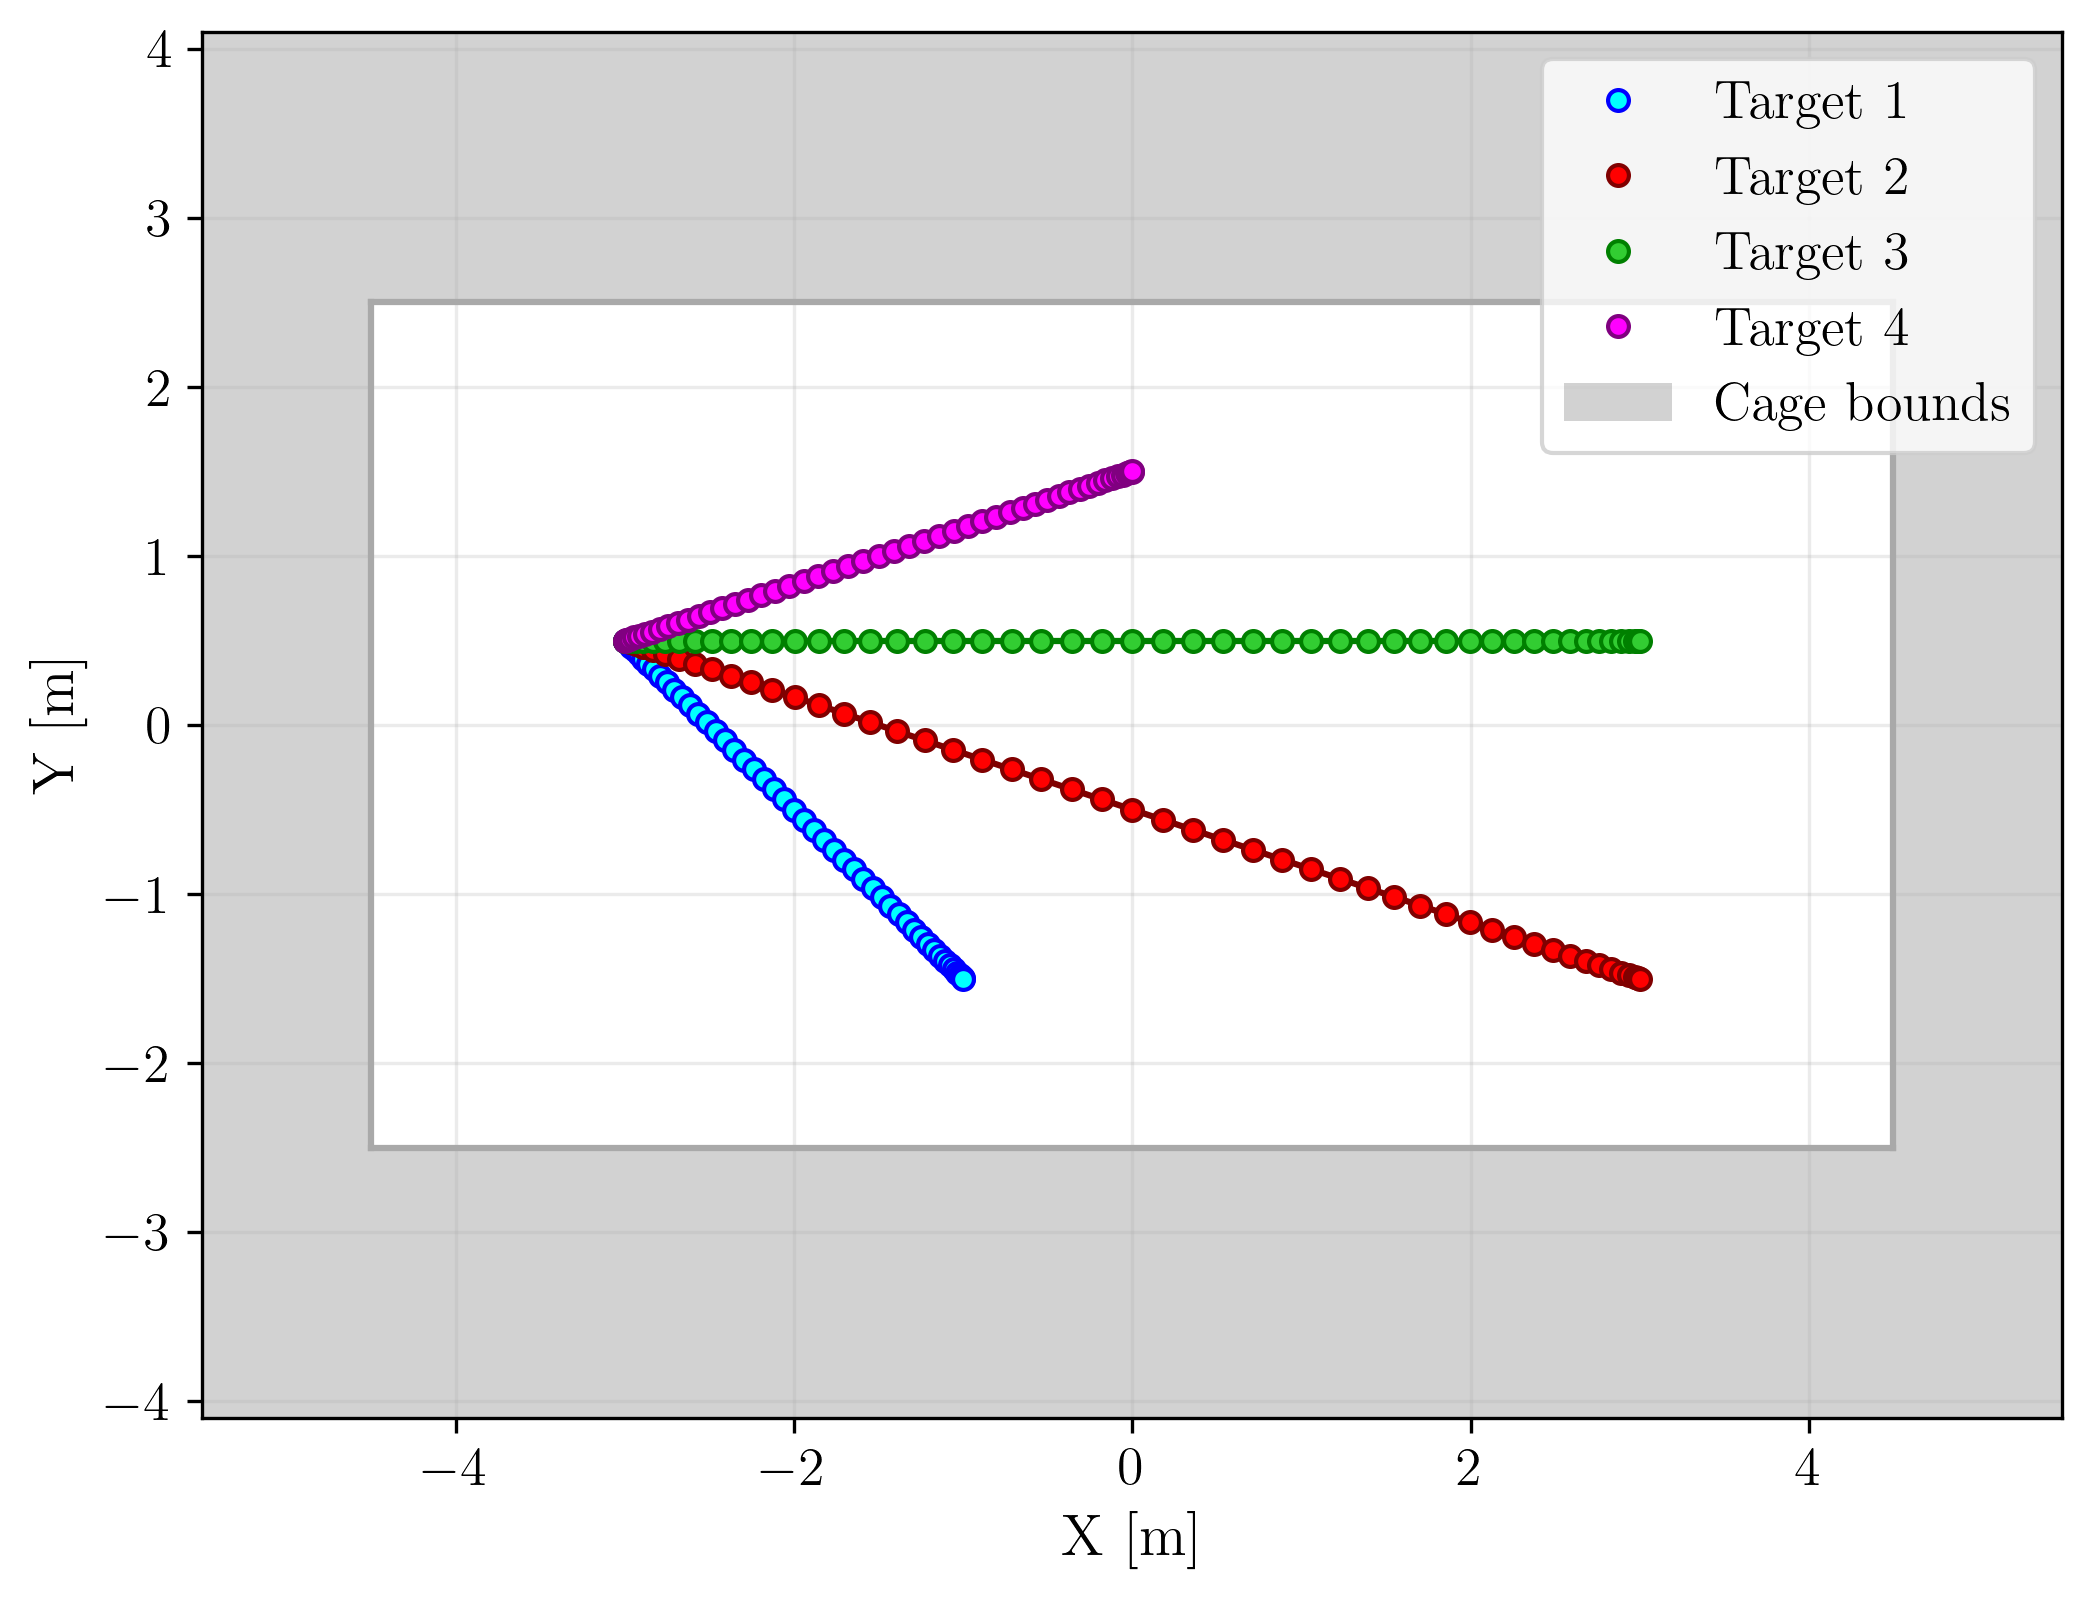

In [ ]:
plot_parametric_trajectories(
    params, 
    opt_solutions, 
    opt_simulations;
    display_obstacles=false,
    fname="decoupled_opt_solutions")
gcf()

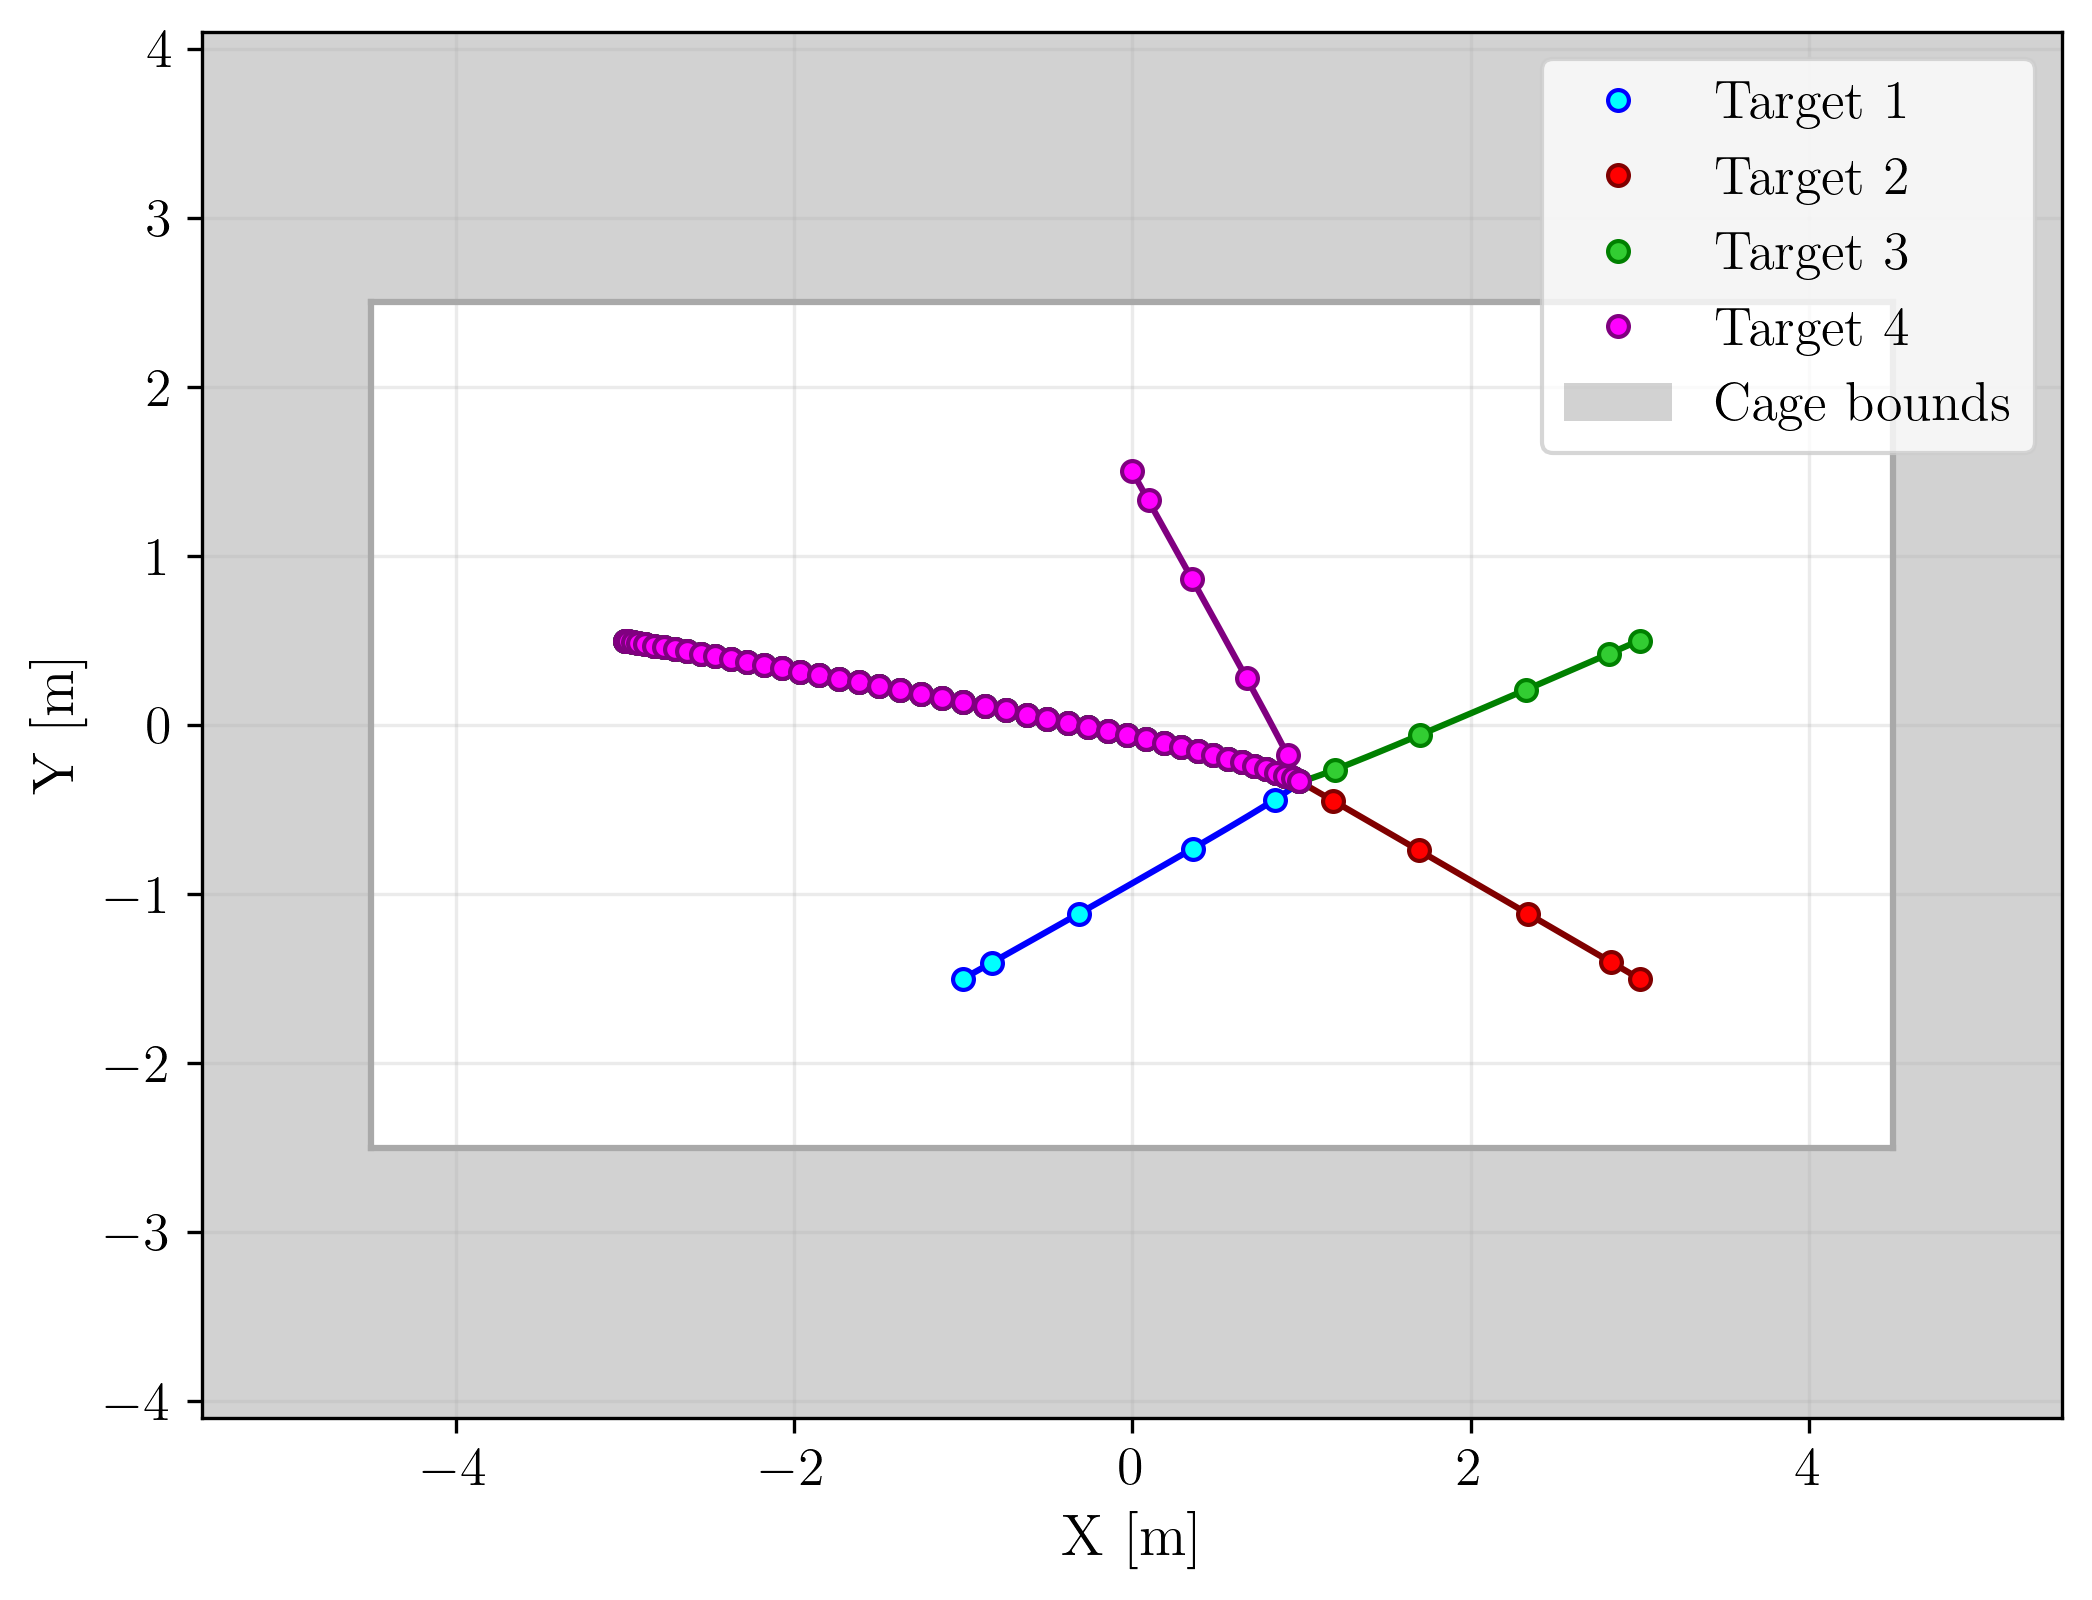

In [ ]:
plot_parametric_trajectories(
    params, 
    ddto_solutions, 
    ddto_simulations;
    display_obstacles=false,
    fname="ddto_solutions")
gcf()